### Thermal Model & Load Profile Analysis

This notebook analyzes the thermal response and electrical load behavior of a
population of building consumer models. It does two main things:

1. **Selects three representative consumers** with fast, medium, and slow
   thermal time constants, and plots their AC power draw and indoor
   temperature over a 3-day window (Figure 1).
2. **Simulates the full 100-consumer population** and plots individual
   consumer load profiles alongside the aggregate cluster load, split into
   cooling (HVAC) and appliance loads (Figure 2).

Both simulations use a static (zero) pricing strategy, so consumer behavior
reflects baseline thermal/appliance dynamics rather than any price response.

In [ ]:
from MultiBuildingRLEnv.evaluation.pricing_strategy import StaticPricingStrategy
from MultiBuildingRLEnv.evaluation.tests import TestPricingStrategy
import dill
import numpy as np
import pandas as pd
from copy import deepcopy
import matplotlib.pyplot as plt

cm_to_inch = 1 / 2.54  # centimeters in inches

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
e:\Anaconda\envs\eaai2026\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [13]:
start_date = "04/15/2022"
end_date = "04/30/2022"

cons_models_file = r"..\data\consumer_models\real_consumer_models_100.dat"
weather_file = r"..\data\SGP_Singapore.486980_IWEC.csv"
with open(cons_models_file, "rb") as ff:
    cons_models = dill.load(ff)

In [14]:
# Identify some consumers that have different very different RC parameters
def calc_time_constant_of_cons_model(cm, settling_steps=2000, measure_steps=40):
    n_steps = settling_steps + measure_steps

    t_amb = [25.0] * n_steps
    t_set = [-10.0] * settling_steps + [100.0] * measure_steps
    index = pd.date_range(start="01/01/2024", freq="15min", periods=n_steps)

    th_mod = deepcopy(cm.th_mod)
    th_mod.reset()
    for t in range(n_steps):
        th_mod.step(t_amb=t_amb[t], t_set=t_set[t], q_irrad=0.0)
    sim_data = th_mod.history.get_pd_series(index)
    t_in = sim_data[0]
    dT_0 = 25 - t_in.iloc[settling_steps - 1]
    dT_t = 25 - t_in.iloc[-1]
    dt = (measure_steps / 4) * 60.0  # in minutes
    return -(dt / np.log(dT_t / dT_0))


reas_cms = [
    cm
    for cm in cons_models
    if (cm.spm.default_setpoint < 25.0 and cm.spm.default_setpoint > 23.0)
]
time_constants = [calc_time_constant_of_cons_model(cm) for cm in reas_cms]

In [15]:
needed_setpoint = 24.0
sorted_indices = np.argsort(time_constants)
sel_cms = [
    reas_cms[sorted_indices[0]],
    reas_cms[sorted_indices[5]],
    reas_cms[sorted_indices[40]],
]

In [16]:
fix_ps = StaticPricingStrategy(0.0)
fix_tps = TestPricingStrategy(
    deepcopy(sel_cms),
    fix_ps,
    (start_date, end_date),
    weather_file,
)
data = fix_tps(True)

C:\Users\shara\AppData\Local\Temp\ipykernel_16856\3873524812.py:86: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax_temp.set_yticklabels(ax_temp.get_yticklabels(), fontsize=label_size)
C:\Users\shara\AppData\Local\Temp\ipykernel_16856\3873524812.py:87: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax_temp_twin.set_yticklabels(ax_temp_twin.get_yticklabels(), fontsize=label_size)


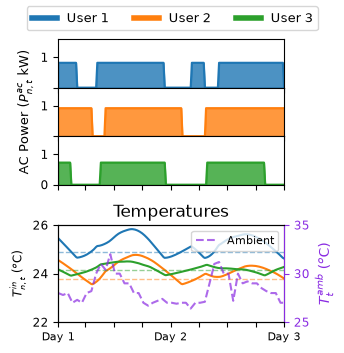

In [17]:
from matplotlib.lines import Line2D

fig = plt.figure(figsize=(9 * cm_to_inch, 9 * cm_to_inch))
gs = fig.add_gridspec(2, 1, height_ratios=[3, 2])
gs0 = gs[0].subgridspec(3, 1, hspace=0.0)
ax_pows = [fig.add_subplot(gs0[i]) for i in range(3)]
for i in range(0, 2):
    ax_pows[i].sharex(ax_pows[2])
ax_pows[2].tick_params(labelbottom=False)
ax_temp = fig.add_subplot(gs[1])
ax_temp_twin = ax_temp.twinx()
idx = fix_tps.index[fix_tps.start_idx : fix_tps.stop_idx]
sub_idx_start = "2022-04-24"
sub_idx_end = "2022-04-25"
xx_plt = range(len(data["net_load"][sub_idx_start:sub_idx_end]))
# Plot the AC powers and temperatures
for ax_pow in ax_pows:
    ax_pow.set(ylim=(0.0, 1.6))
ax_pows[1].set_ylabel("AC Power ($P^{ac}_{n,t}$ kW)")
ax_temp.set(
    title="Temperatures",
    ylabel="$T^{in}_{n,t}$ (${}^o$C)",
    ylim=(22, 26),
    xlim=(min(xx_plt), max(xx_plt)),
)
ax_temp_twin.set(
    ylabel="$T^{amb}_t$ (${}^o$C)", ylim=(25, 35), xlim=(min(xx_plt), max(xx_plt))
)
ax_temp_twin.tick_params(axis="y", colors="blueviolet")
ax_temp_twin.yaxis.label.set_color("blueviolet")
ax_temp_twin.spines["right"].set_color("blueviolet")
ax_temp_twin.plot(
    xx_plt,
    fix_tps.t_amb[sub_idx_start:sub_idx_end],
    c=f"blueviolet",
    linestyle="--",
    alpha=0.7,
    label="Ambient",
)

for ix, cm in enumerate(fix_tps.cms):
    t_in, te, tia, p_ac = cm.th_mod.history.get_pd_series(idx)
    p_ac = p_ac / 1000.0
    ax_pows[ix].plot(
        p_ac[sub_idx_start:sub_idx_end].to_numpy(), c=f"C{ix}", label=f"Cons {ix+1}"
    )
    ax_pows[ix].fill_between(
        xx_plt,
        np.zeros_like(xx_plt),
        p_ac[sub_idx_start:sub_idx_end],
        color=f"C{ix}",
        alpha=0.8,
    )
    ax_pows[ix].tick_params(labelbottom=False)
    ax_pows[ix].set(xlim=(min(xx_plt), max(xx_plt)))
    ax_pows[ix].set_yticks([0, 1])
    if ix == 2:
        ax_pows[ix].set_yticklabels(["0", "1"])
    else:
        ax_pows[ix].set_yticklabels(["", "1"])
    ax_temp.plot(xx_plt, t_in[sub_idx_start:sub_idx_end].to_numpy(), c=f"C{ix}")
    ax_temp.axhline(
        y=cm.spm.default_setpoint,
        xmin=min(xx_plt),
        xmax=max(xx_plt),
        color=f"C{ix}",
        linestyle="--",
        linewidth=1,
        alpha=0.5,
    )
ax_temp.set_xticks(
    [
        0,
        23,
        47,
        71,
        95,
        119,
        143,
        167,
        191,
    ]
)
label_size = 8.5
ax_temp.set_xticklabels(["Day 1", "", "", "", "Day 2", "", "", "", "Day 3"], fontsize=8)
ax_temp.set_yticklabels(ax_temp.get_yticklabels(), fontsize=label_size)
ax_temp_twin.set_yticklabels(ax_temp_twin.get_yticklabels(), fontsize=label_size)
ax_temp.xaxis.label.set_size(label_size)
ax_temp.yaxis.label.set_size(label_size)
for ax in ax_pows:
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=label_size)
    ax.xaxis.label.set_size(label_size)
    ax.yaxis.label.set_size(label_size + 1)
    ax.set_xticks(
        [
            0,
            23,
            47,
            71,
            95,
            119,
            143,
            167,
            191,
        ]
    )
# Plot the temperatures
ax_temp_twin.legend(prop={"size": 8})
custom_lines = [
    Line2D([0], [0], color="C0", lw=4),
    Line2D([0], [0], color="C1", lw=4),
    Line2D([0], [0], color="C2", lw=4),
]
fig.legend(
    custom_lines,
    ["User 1", "User 2", "User 3"],
    loc="outside upper center",
    ncol=3,
    prop={"size": 9},
)
fig.tight_layout()
fig.subplots_adjust(top=0.9)

fig.savefig("figures/thermal_model_op.png", dpi=400, bbox_inches="tight")

In [18]:
fix_tps_b = TestPricingStrategy(
    cons_models,
    fix_ps,
    (start_date, end_date),
    weather_file,
)
data_b = fix_tps_b(True)

In [19]:
get_hourly_means = lambda s: s.to_numpy().reshape(-1, 96).mean(axis=0)


def plot_cm_load_to_ax(cm, ax, date=None, label_idx=None):
    # Get the data
    idx = fix_tps_b.index[fix_tps_b.start_idx : fix_tps_b.stop_idx]
    t_in, te, tia, p_ac = cm.th_mod.history.get_pd_series(idx)
    nl = pd.Series(cm.net_load, index=idx)
    el = nl - p_ac
    if date is None:
        # Get the average hourly thing
        t_el = get_hourly_means(el) / 1000
        t_ac = get_hourly_means(p_ac) / 1000
    else:
        t_el = el[date].to_numpy() / 1000
        t_ac = p_ac[date].to_numpy() / 1000
    # Fill the axis
    ax.grid(alpha=0.4)
    ax.fill_between(range(96), np.zeros(96), t_el + t_ac)
    ax.fill_between(range(96), np.zeros(96), t_el)
    ax.set_xticks([0, 23, 47, 71, 95])
    ax.set_xticklabels(["", "6 AM", "12 PM", "6 PM", ""])
    ax.set_yticks([0, 2, 4, 6])
    ax.set_yticklabels(["0", "2", "4", "6"])
    ax.set(xlim=(0, 96), ylim=(0, 6), ylabel="Power (kW)")
    # Text if needed
    if label_idx is not None:
        ax.text(71, 5, f"Consumer $n_{label_idx}$", ha="center")


def get_total_hvac_load(tps: TestPricingStrategy):
    idx = tps.index[tps.start_idx : tps.stop_idx]
    total_hvac = pd.Series(0, index=idx)
    for cm in tps.cms:
        t_in, te, tia, p_ac = cm.th_mod.history.get_pd_series(idx)
        total_hvac += p_ac
    return total_hvac

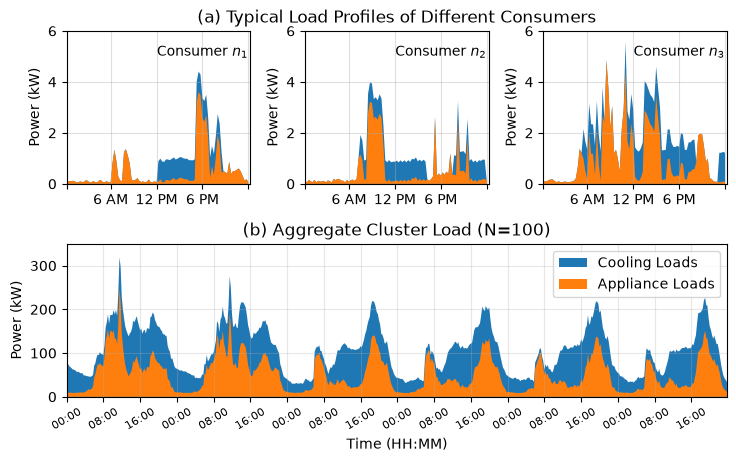

In [20]:
# Set the date
import matplotlib.dates as mdates

date = "2022-04-29"
# Create the subplots
fig = plt.figure(figsize=(19 * cm_to_inch, 12 * cm_to_inch))
gs = fig.add_gridspec(2, 3)
ax_c1 = fig.add_subplot(gs[0, 0])
ax_c2 = fig.add_subplot(gs[0, 1])
ax_c3 = fig.add_subplot(gs[0, 2])
ax_nl = fig.add_subplot(gs[1, :])
# Add the individual consumers
ax_c2.set(title="(a) Typical Load Profiles of Different Consumers")
plot_cm_load_to_ax(fix_tps_b.cms[8], ax_c1, date, 1)
plot_cm_load_to_ax(fix_tps_b.cms[6], ax_c2, date, 2)
plot_cm_load_to_ax(fix_tps_b.cms[45], ax_c3, date, 3)
# Add the net load over a period of a few weeks
sub_idx_start = "2022-04-23"
sub_idx_end = "2022-04-28"
nl = data_b["net_load"][sub_idx_start:sub_idx_end] / 1000.0
hv = get_total_hvac_load(fix_tps_b)[sub_idx_start:sub_idx_end] / 1000.0
el = nl - hv
ax_nl.set(
    title="(b) Aggregate Cluster Load (N=100)",
    ylim=(0, 350),
    xlim=(el.index.min(), el.index.max()),
    xlabel="Time (HH:MM)",
    ylabel="Power (kW)",
)
ax_nl.fill_between(el.index, np.zeros(len(el.index)), nl, label="Cooling Loads")
ax_nl.fill_between(el.index, np.zeros(len(el.index)), el, label="Appliance Loads")
ax_nl.legend()
# Use HourLocator for ticks at 0, 8, 16, and 24 hours
locator = mdates.HourLocator(byhour=[0, 8, 16, 24])
ax_nl.xaxis.set_major_locator(locator)
# Format the x-axis to display hours only (HH:MM format)
ax_nl.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax_nl.tick_params(axis="x", labelrotation=30, labelsize=8)
ax_nl.grid(axis="both", alpha=0.3)
fig.tight_layout()
fig.savefig("figures/load_profiles_cluster.png", dpi=350, bbox_inches="tight")